# Predicting Diabetes Risk Using Health Indicators: A Data-Driven Approach to Early Detection and Prevention

This project leverages machine learning techniques and Python-based data science libraries to develop a predictive model for diabetes risk. By analyzing key health indicators, the model aims to support early detection and preventation masures, contributing to improved healthcare outcomes.

We'll take the following approach:
1. Problem Definition
2. Data
3. Evaluation
4. Features
5. Modeling
6. Experimentation

## 1. Problem Definition
The primary problem we aim to solve is identifying individuals at risk of diabetes by analyzing health indicators. This predictive model will support early diagnosis and enable targeted preventive healthcare interventions, ultimately reducing diabetes-related health complications and healthcare costs.

## 2. Data
The original data is available on Kaggle:
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset/data

## 3. Evaluation
If the model achieves 95% accuracy in predicting diabetes risk during the proof of concept, we will proceed with further development of the project.

## 4. Features
1. **Diabetes_binary:** A categorical variable indicating whether the person has diabetes (1 = Yes, 0 = No).
2. **HighBP:** Whether the person has high blood pressure (1 = Yes, 0 = No).
3. **HighChol:** Whether the person has high cholesterol (1 = Yes, 0 = No).
4. **CholCheck:** Whether the person has had a cholesterol check in the past 5 years (1 = Yes, 0 = No).
5. **BMI:** Body Mass Index (BMI), a measure of body fat based on height and weight.
6. **Smoker:** Whether the person is a smoker (1 = Yes, 0 = No).
7. **Stroke:** Whether the person has had a stroke (1 = Yes, 0 = No).
8. **HeartDiseaseorAttack:** Whether the person has a history of heart disease or heart attack (1 = Yes, 0 = No).
9. **PhysActivity:** Whether the person engages in physical activity (1 = Yes, 0 = No).
10. **Fruits:** Whether the person eats fruits daily (1 = Yes, 0 = No).
11. **Veggies:** Whether the person eats vegetables daily (1 = Yes, 0 = No).
12. **HvyAlcoholConsump:** Whether the person engages in heavy alcohol consumption (1 = Yes, 0 = No).
13. **AnyHealthcare:** Whether the person has access to any healthcare (1 = Yes, 0 = No).
14. **NoDocbcCost:** Whether the person has not seen a doctor due to cost (1 = Yes, 0 = No).
15. **GenHlth:** Self-rated general health (Excellent, Very Good, Good, Fair, Poor).
16. **MentHlth:** Number of days in the past 30 days when the person’s mental health was not good.
17. **PhysHlth:** Number of days in the past 30 days when the person’s physical health was not good.
18. **DiffWalk:** Whether the person has difficulty walking or climbing stairs (1 = Yes, 0 = No).
19. **Sex:** Gender of the person (1 = Male, 0 = Female).
20. **Age:** Age of the person.
21. **Education:** Education level (1 = Less than high school, 2 = High school graduate, 3 = Some college or technical school, 4 = College graduate).
22. **Income:** Annual household income:
     - 1 = Less than $10,000
     - 2 = $10,000-$14,999
     - 3 = $15,000-$19,999
     - 4 = $20,000-$24,999
     - 5 = $25,000-$34,999
     - 6 = $35,000-$44,999
     - 7 = $45,000-$54,999
     - 8 = $55,000-$64,999
     - 9 = $65,000-$74,999
     - 10 = $75,000 and above

## Data Analysis

In [1]:
# Regular EAD (Exploratory Data Analysis) and plotting libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Data Loading

In [2]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Diabetes/diabetes_binary_health_indicators_BRFSS2015.csv')

# Check dataset dimensions (rows, columns)
df.shape

(253680, 22)

##### Data Exploration (EDA - Exploratory Data Analysis)
Our goal is to thoroughly understand the Diabetes Health Indicators dataset so that we can become subject matter experts on the data we're working with.
The key questins we'll address during the Exploratory Data Analysis (EDA) are:
1. **What question(s) are we trying to solve?**
   
   In this project, we aim to predict whether a patient is at risk of diabetes based on their health indicators, such as BMI, blood pressure, cholesterol levels, and lifestyle factors.

2. **What kind of data do we have, and how do we treat different types?**

     We need to explore the dataset to identify the types of data (numerical, categorical, etc.) and determine the appropriate methods for handling each type during analysis and modeling. For example, numerical values might need scaling, while categorical variables may require encoding.

3. **What's missing from the data, and how is it dealt with?**

   We'll examine the dataset for any missing values, as incomplete data can negatively impact model performance. Strategies like imputation (filling in missing values) or removing rows/columns with missing data may be necessary.

4. **Where are the outliers, and why should they be addressed?**

   Outliers—data points that differ significantly from the rest—can distort the results and affect the accuracy of our model. Identifying and appropriately handling outliers will be crucial to building a robust model.

5. **How can we add, change, or remove features to extract more value from the data?**

    Feature engineering involves creating new features or modifying existing ones to improve model performance. We may also consider removing irrelevant or redundant features that don’t contribute meaningfully to the prediction task   

In [3]:
# Preview the first 5 rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [4]:
# Preview the columns
df.head().T

,0,1,2,3,4
Diabetes_binary,0.0,0.0,0.0,0.0,0.0
HighBP,1.0,0.0,1.0,1.0,1.0
HighChol,1.0,0.0,1.0,0.0,1.0
CholCheck,1.0,0.0,1.0,1.0,1.0
BMI,40.0,25.0,28.0,27.0,24.0
Smoker,1.0,1.0,0.0,0.0,0.0
Stroke,0.0,0.0,0.0,0.0,0.0
HeartDiseaseorAttack,0.0,0.0,0.0,0.0,0.0
PhysActivity,0.0,1.0,0.0,1.0,1.0
Fruits,0.0,0.0,1.0,1.0,1.0


In [5]:
# As Diabetes_binary is the target itself, we'll change its name to target, for simplicity
df.rename(columns={'Diabetes_binary': 'target'}, inplace=True)

# Check
df.head()

,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


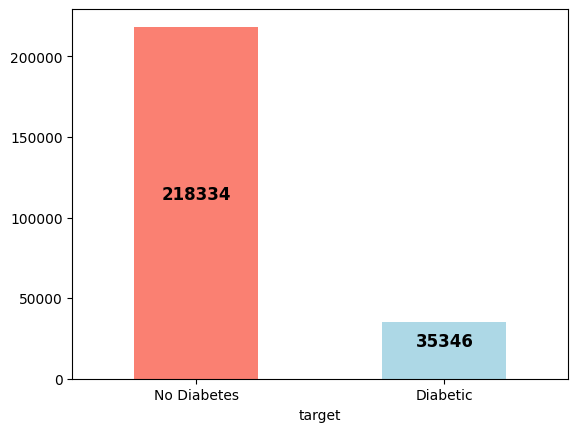

In [6]:
# Count instances in 'target' column
target_instances = df['target'].value_counts()

# Plot class distribution
target_distribution = target_instances.plot(kind="bar", color=['salmon', "lightblue"])

# Annotate bars with counts
for index, value in enumerate(target_instances):
    target_distribution.text(index, value/2, str(value), ha="center",
                            va="bottom", fontsize=12, color="black", fontweight="bold")

# Set x-axis labels and display plot
plt.xticks([0, 1], ["No Diabetes", "Diabetic"], rotation=0)
plt.show()

In [7]:
# Display concise DataFrame summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   target                253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [8]:
# Check for missing values
df.isna().sum()

,0
target,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [9]:
# Descriptive statistics
df.describe()

,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


#### Diabetes Risk Factors
##### Diabetes Frequency according to Sex

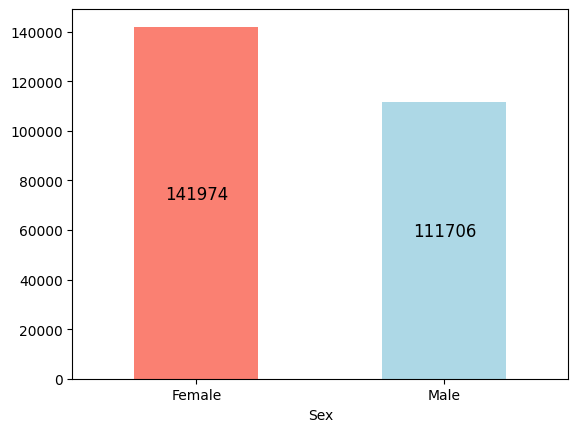

In [10]:
# Count occurences in 'sex' column
sex_occurences = df['Sex'].value_counts()

# Plot gender distribution
gender_distribution = sex_occurences.plot(kind="bar", color=['salmon', "lightblue"])

# Annotate bars with counts
for index, value in enumerate(sex_occurences):
    gender_distribution.text(index, value/2, str(value), ha="center",
                            va="bottom", fontsize=12, color="black")

# Set x-axis labels and display plot
plt.xticks([0, 1], ['Female', 'Male'], rotation=0);

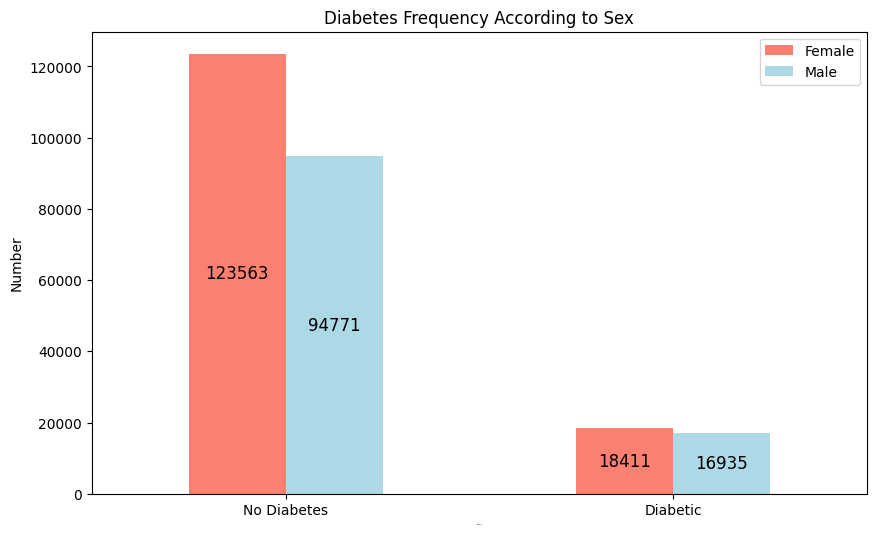

In [11]:
# Comapre target and sex with a crosstab
sex_target = pd.crosstab(df['target'], df['Sex'])

# Plot crosstab
sex_target_crosstab = sex_target.plot(kind="bar", figsize=(10, 6),
                                     color=['salmon', 'lightblue'])

# Annotate bars with counts
for i in sex_target_crosstab.containers:
    sex_target_crosstab.bar_label(i, label_type="center", fontsize=12,
                                 color="black")

# Set plot title, labels, and legend
plt.title("Diabetes Frequency According to Sex")
plt.xlabel("Disease", fontsize=1)
plt.ylabel("Number")
plt.legend(['Female', 'Male'])
plt.xticks([0, 1], ["No Diabetes", "Diabetic"], rotation=0);

#### Health Indicators and Diabetes Risk
We will compare the full set of health indicators to diabetes risk, which include:
- HighBP: High Blood Pressure
- HighChol: High Cholesterol
- BMI: Body Mass Index
- Stroke: History of Stroke
- target: The target variable (whether or not a person is at risk of diabetes)

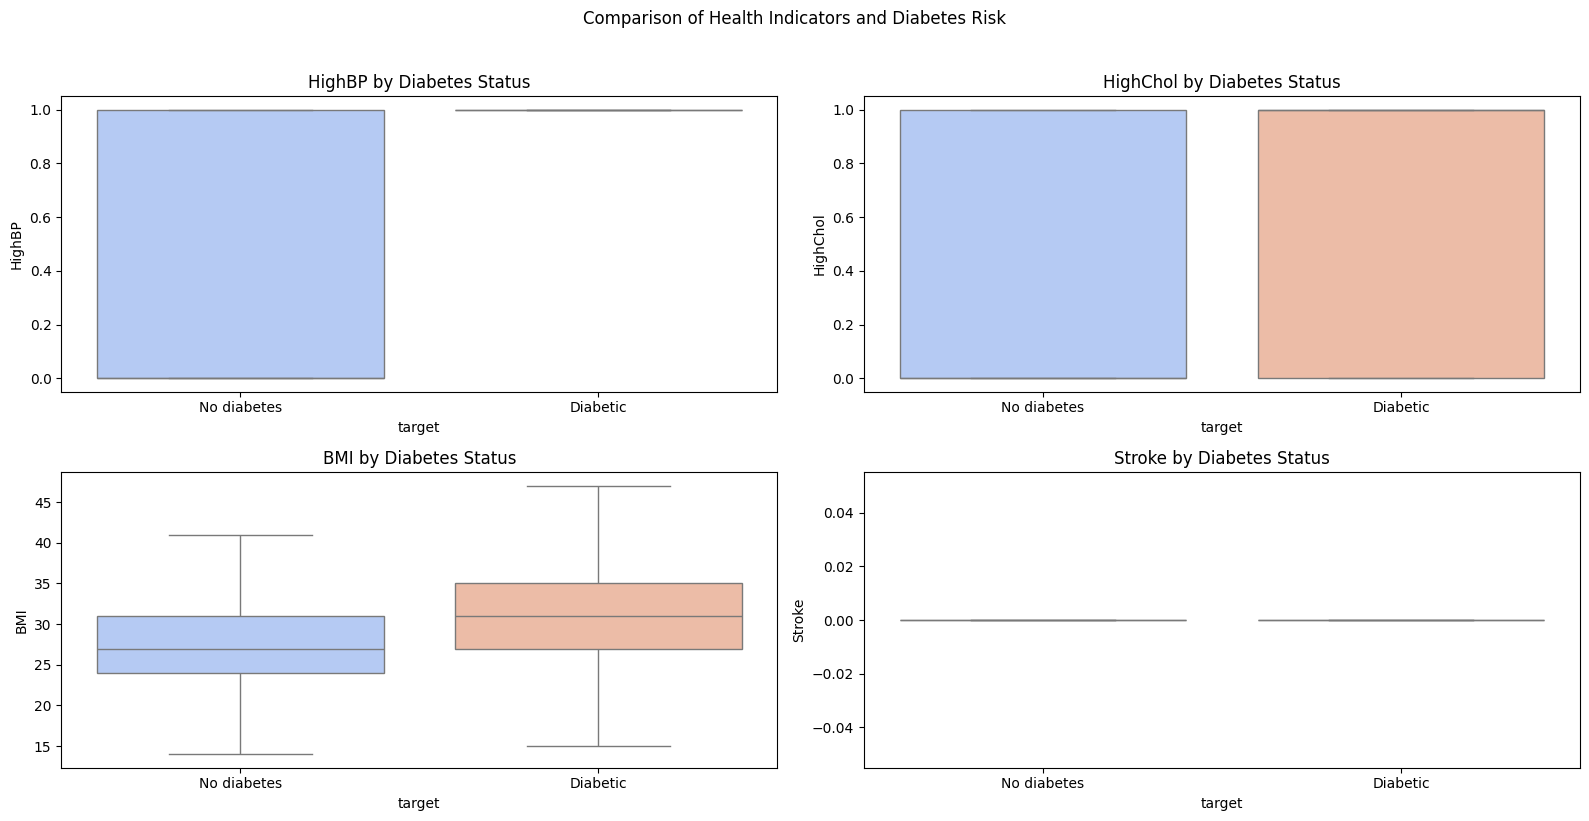

In [12]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: "No diabetes", 1: "Diabetic"})

# Selecting the columns for health indicators and diabetes risk
health_indicators = ['HighBP', 'HighChol', 'BMI', 'Stroke']

# Set up the figure layout
plt.figure(figsize=(16, 8))

# Loop through health indicators and create a box plot for each
for i, indicator in enumerate(health_indicators, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='target', y=indicator, data=df_temp, hue='target', palette='coolwarm', dodge=False, showfliers=False)
    plt.title(f'{indicator} by Diabetes Status')

# Adjust layout and add a main title
plt.suptitle("Comparison of Health Indicators and Diabetes Risk", y=1.02)
plt.tight_layout()
plt.show()

#### Lifestyle Factors
We will compare the full set of Lifestyle factors to diabetes risk, which include:
- Physical Activity
- Dietary Habits
- Smoking
- target

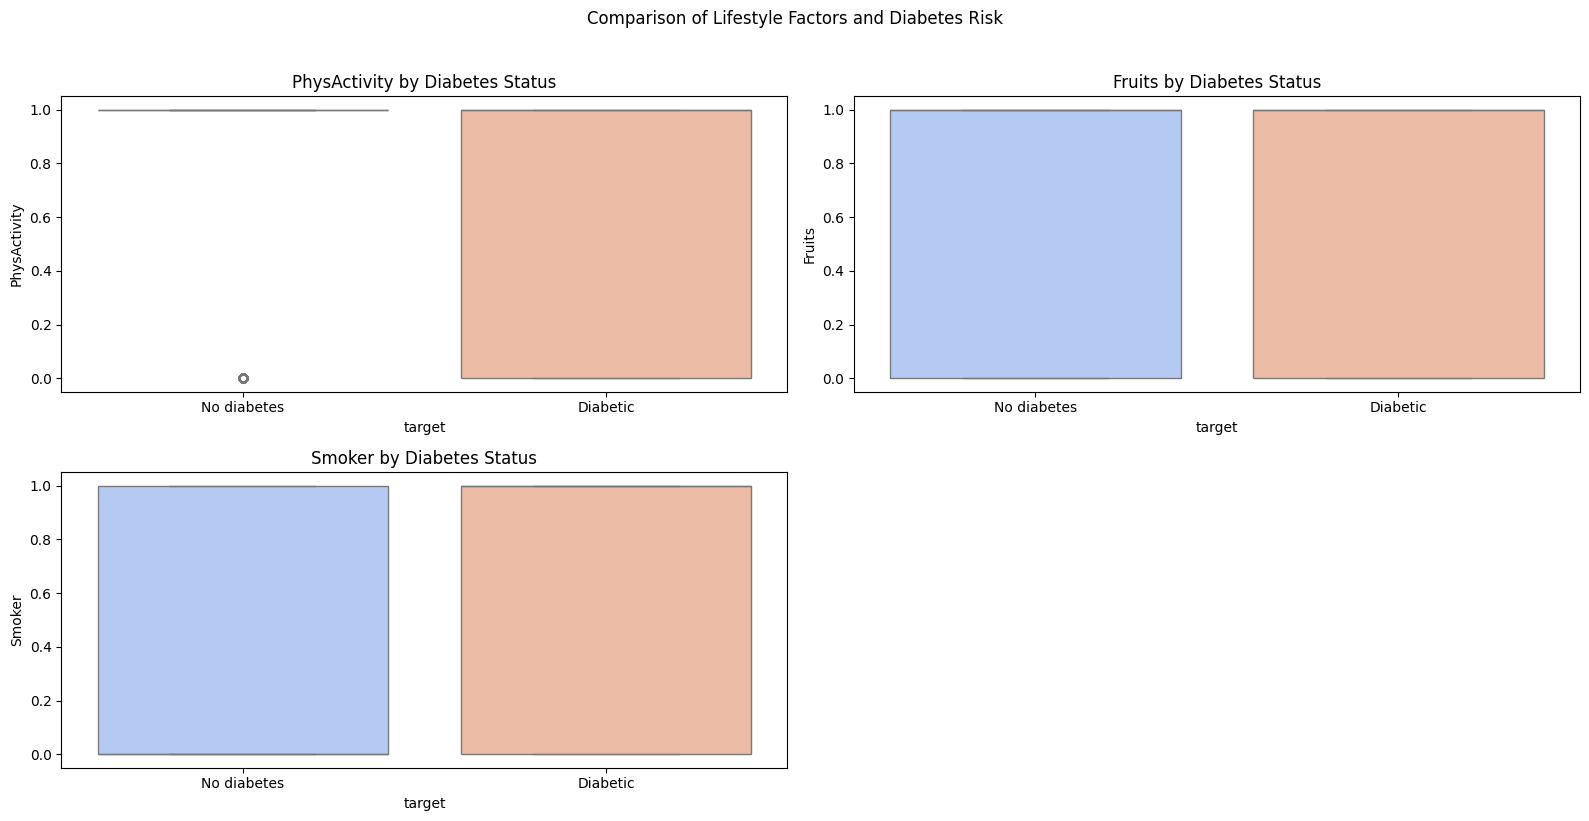

In [13]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Selecting the columns for lifestyle factors and diabetes risk
lifestyle_factors = ['PhysActivity', 'Fruits', 'Smoker']

# Set up the figure layout
plt.figure(figsize=(16, 8))

# Loop through lifestyle factors and create a box plot for each
for i, factor in enumerate(lifestyle_factors, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='target', y=factor, data=df_temp, hue='target', palette='coolwarm', dodge=False)
    plt.title(f'{factor} by Diabetes Status')

# Adjust layout and add a main title
plt.suptitle("Comparison of Lifestyle Factors and Diabetes Risk", y=1.02)
plt.tight_layout()
plt.show()


#### Healthcare Access
We will compare the full set of healthcare access, including:
- Healthcare access
- Cost barriers

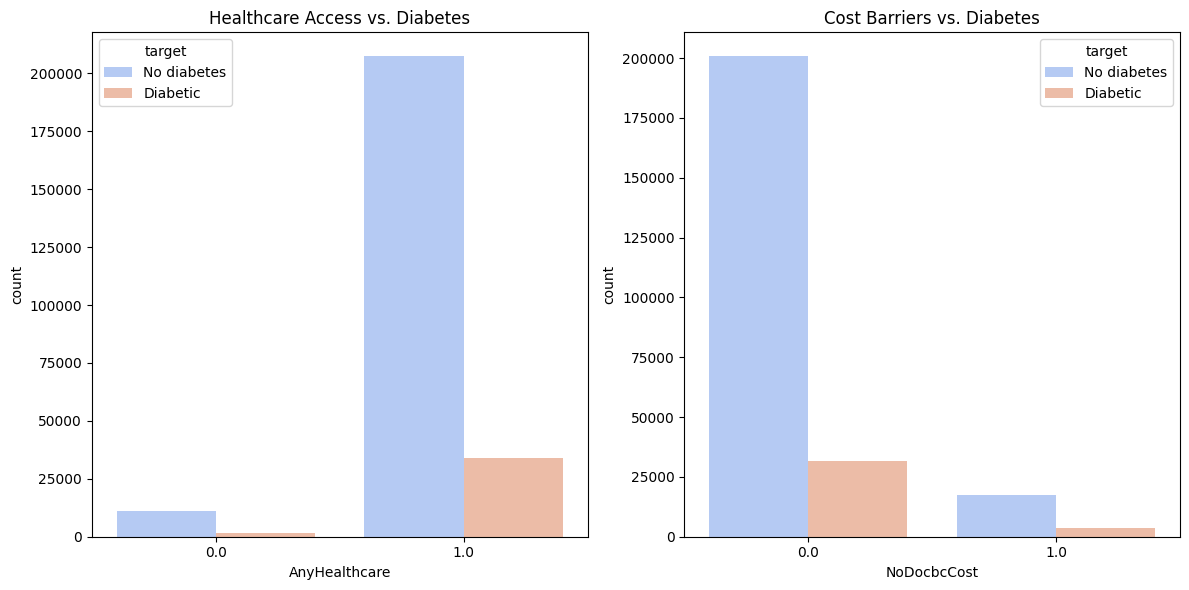

In [14]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Selecting the columns for healthcare access and diabetes risk
healthcare_factors = ['AnyHealthcare', 'NoDocbcCost', 'target']

# Creating countplots for Healthcare Access and Cost Barriers vs Diabetes Risk
plt.figure(figsize=(12, 6))

# Healthcare Access vs Diabetes
plt.subplot(1, 2, 1)
sns.countplot(x='AnyHealthcare', hue='target', data=df_temp, palette='coolwarm')
plt.title('Healthcare Access vs. Diabetes')

# Cost Barriers vs Diabetes
plt.subplot(1, 2, 2)
sns.countplot(x='NoDocbcCost', hue='target', data=df_temp, palette='coolwarm')
plt.title('Cost Barriers vs. Diabetes')

# Show the plot
plt.tight_layout()
plt.show()

#### Demographic
We will compare the full set of demography, including:
- Age
- Income
- Education

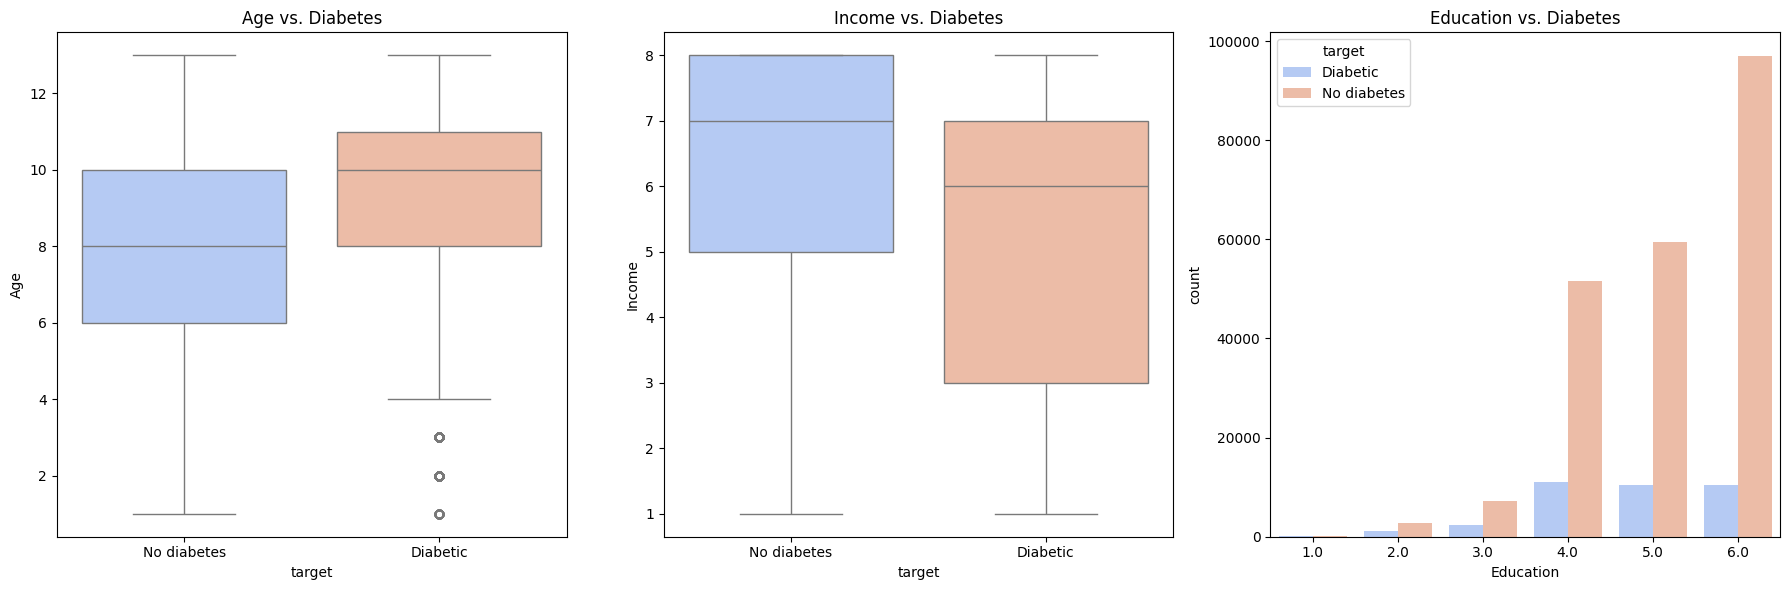

In [15]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Creating subplots to compare demographic factors
plt.figure(figsize=(18, 6))

# Age vs Diabetes
plt.subplot(1, 3, 1)
sns.boxplot(x='target', y='Age', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Age vs. Diabetes')

# Income vs Diabetes
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='Income', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Income vs. Diabetes')

# Education vs Diabetes (Categorical)
plt.subplot(1, 3, 3)
sns.countplot(x='Education', hue='target', data=df_temp, palette='coolwarm')
plt.title('Education vs. Diabetes')

# Show the plot
plt.tight_layout()
plt.show()

#### Self-reported Health Status

- General Health
- Physical Health
- Mental Health

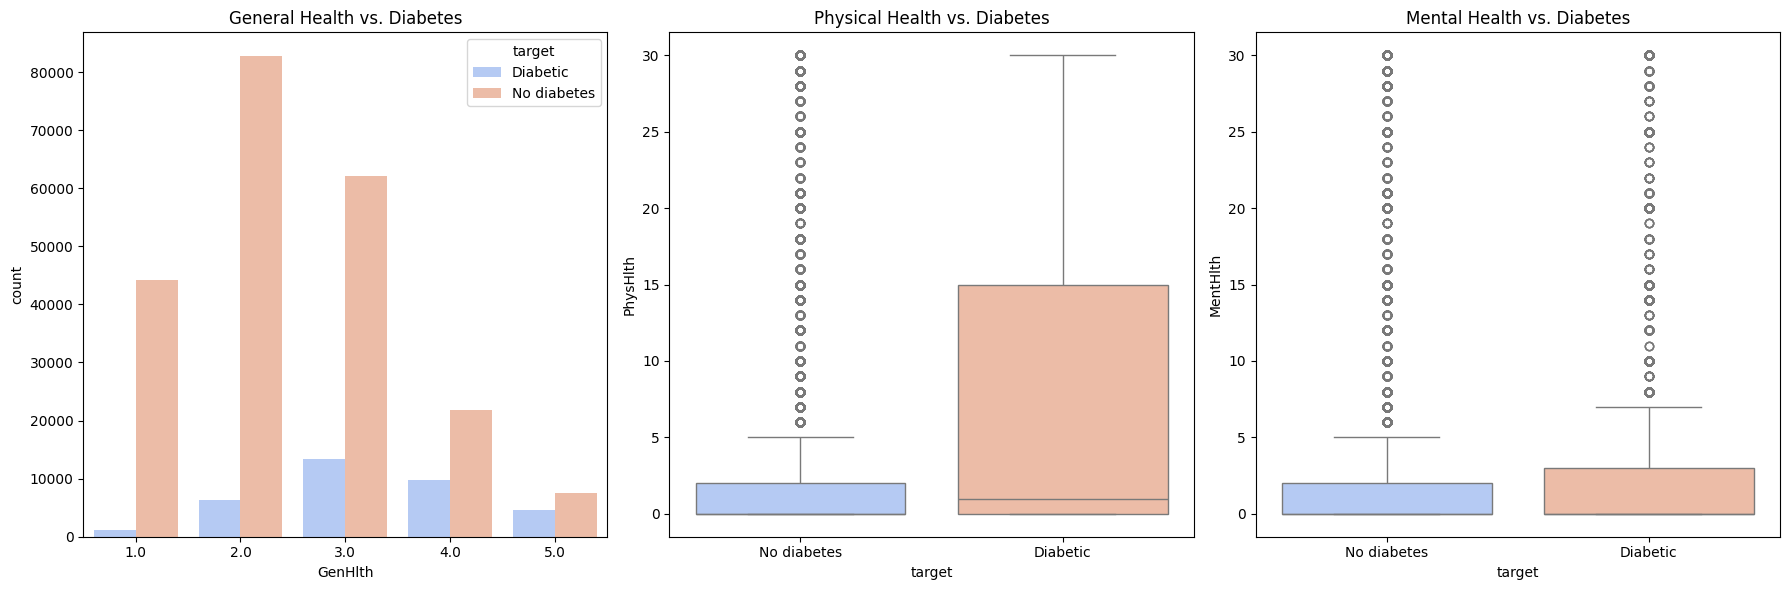

In [16]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Creating subplots to compare self-reported health status factors
plt.figure(figsize=(18, 6))

# General Health vs Diabetes (Categorical)
plt.subplot(1, 3, 1)
sns.countplot(x='GenHlth', hue='target', data=df_temp, palette='coolwarm')
plt.title('General Health vs. Diabetes')

# Physical Health vs Diabetes
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='PhysHlth', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Physical Health vs. Diabetes')

# Mental Health vs Diabetes
plt.subplot(1, 3, 3)
sns.boxplot(x='target', y='MentHlth', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Mental Health vs. Diabetes')

# Show the plot
plt.tight_layout()
plt.show()

#### Outlier Detection

- BMI
- Physical Health Days in relation to Age and Diabetes Risk

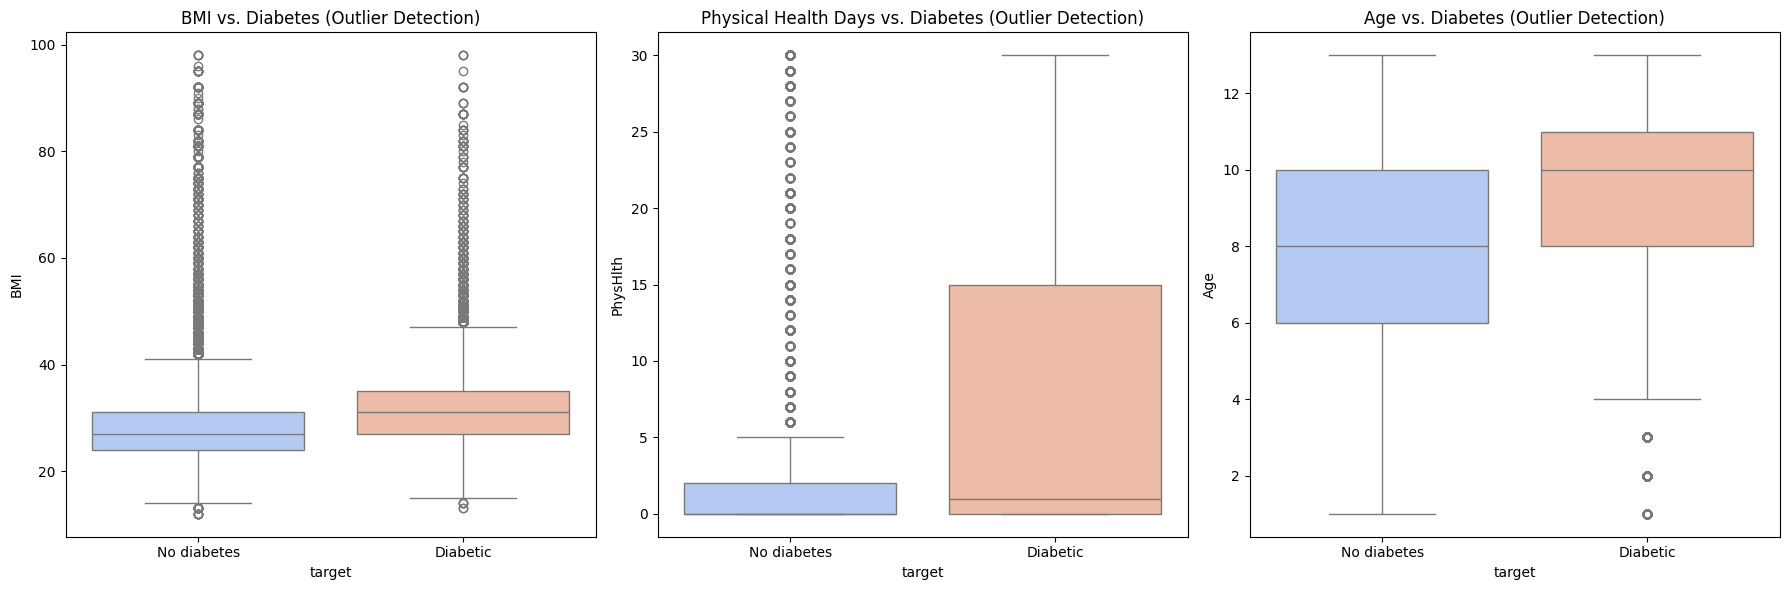

In [17]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Creating subplots to compare outlier detection factors
plt.figure(figsize=(18, 6))

# BMI vs Diabetes (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x='target', y='BMI', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('BMI vs. Diabetes (Outlier Detection)')

# Physical Health Days vs Diabetes (Boxplot)
plt.subplot(1, 3, 2)
sns.boxplot(x='target', y='PhysHlth', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Physical Health Days vs. Diabetes (Outlier Detection)')

# Age vs Diabetes (Boxplot)
plt.subplot(1, 3, 3)
sns.boxplot(x='target', y='Age', data=df_temp, hue='target', palette='coolwarm', legend=False)
plt.title('Age vs. Diabetes (Outlier Detection)')

# Show the plot
plt.tight_layout()
plt.show()

#### Health Risk Factors by Demographics
- Gender vs Diabetes for BMI and Blood Pressure
- Income vs Diabetes History

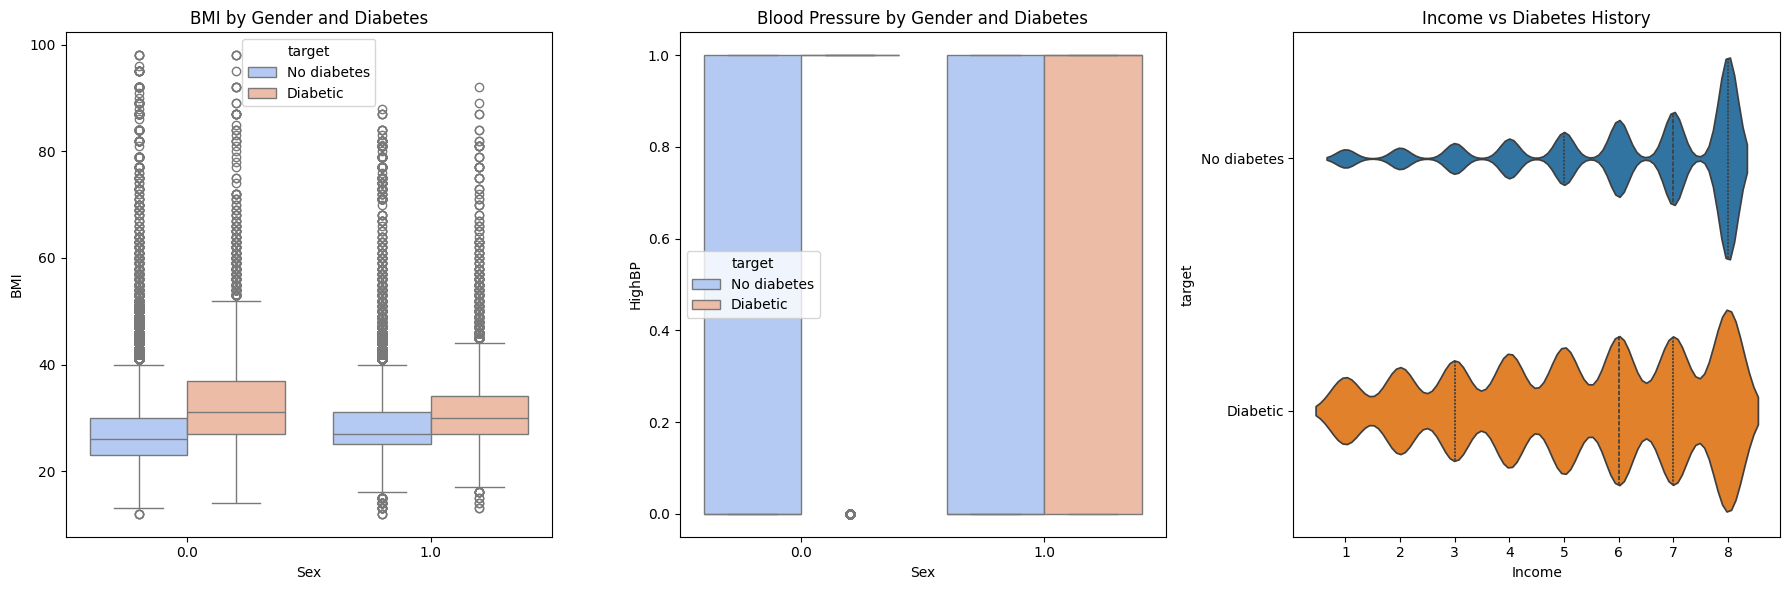

In [18]:
# Create a temporary copy of the dataframe
df_temp = df.copy()

# Rename the target column temporarily for clarity in the plot
df_temp['target'] = df_temp['target'].map({0: 'No diabetes', 1: 'Diabetic'})

# Set up the figure layout
plt.figure(figsize=(18, 6))

# Gender vs Diabetes: BMI (Boxplot)
plt.subplot(1, 3, 1)
sns.boxplot(x='Sex', y='BMI', hue='target', data=df_temp, palette='coolwarm')
plt.title('BMI by Gender and Diabetes')

# Gender vs Diabetes: Blood Pressure (Boxplot)
plt.subplot(1, 3, 2)
sns.boxplot(x='Sex', y='HighBP', hue='target', data=df_temp, palette='coolwarm')
plt.title('Blood Pressure by Gender and Diabetes')

# Income vs History of Diabetes (Violin Plot) - using hue for color grouping
plt.subplot(1, 3, 3)
sns.violinplot(x='Income', y='target', data=df_temp, hue='target', inner='quartile', legend=False)
plt.title('Income vs Diabetes History')

# Adjust layout
plt.tight_layout()
plt.show()

#### Make a correlation matrix

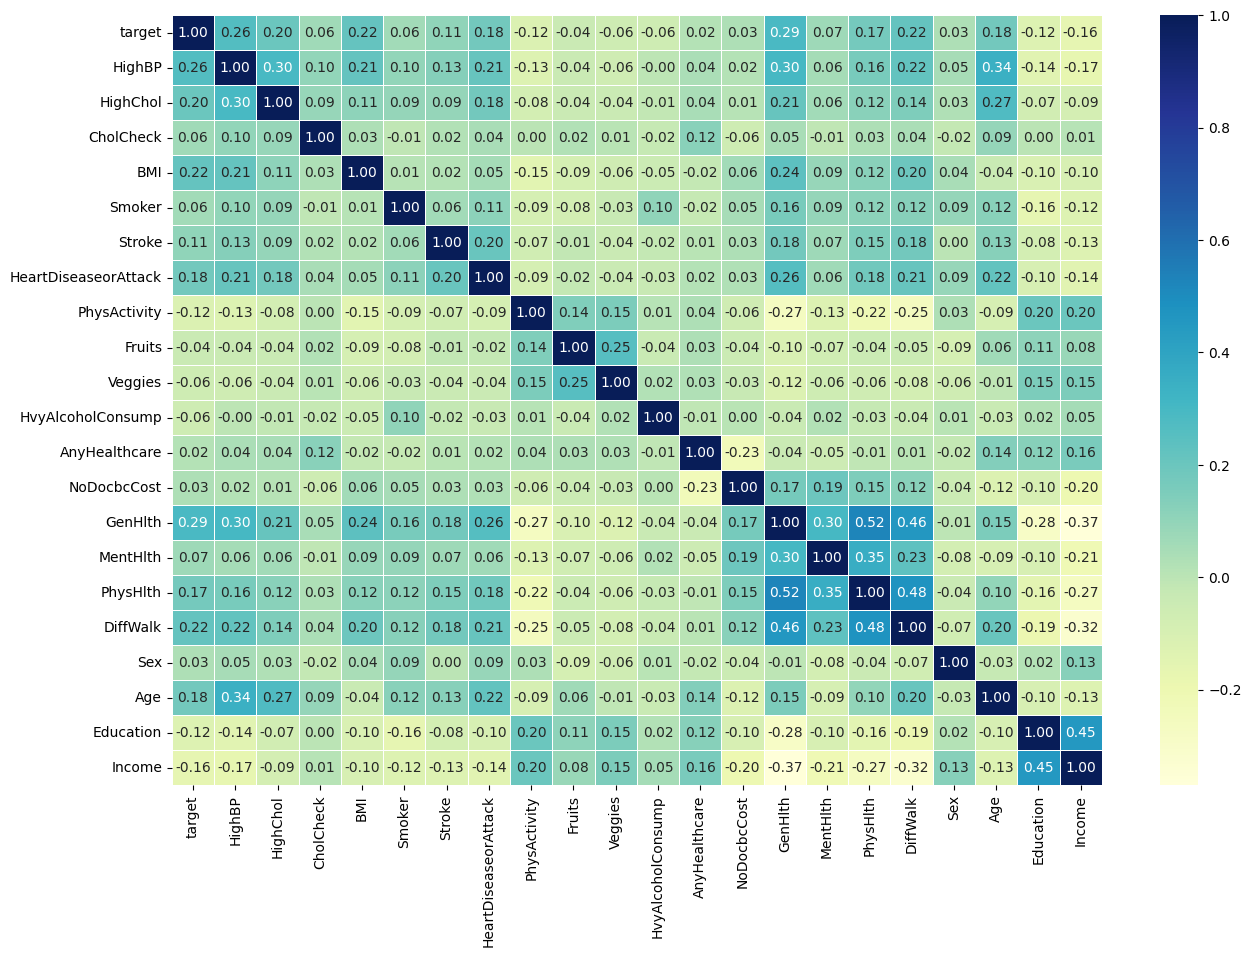

In [19]:
# Create and plot correlation matrix
correlation_matrix = df.corr()
fig, ax = plt.subplots(figsize=(15, 10))
ax = sns.heatmap(correlation_matrix, annot=True, linewidths=0.5,
                fmt=".2f", cmap="YlGnBu");

###  Modeling

In [20]:
# Review the data
df.head()

,target,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [21]:
# Split data into features and labels
X = df.drop('target', axis=1)
y = df['target']

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [23]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=42)

In [24]:
# Initialze the scaler
scaler = StandardScaler()

# Fit the scaler on the training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the transformation to the test data
X_test_scaled = scaler.transform(X_test)

Now that we've got our data split into training and test sets, and scaled the training sets, it's time to build a machine learning model.

We'll train it (find the patterns) on the training set.

And we'll test it (use the patterns) on the test set.

We're going to try several different machine learning models, namely:

1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Decision Tree Classifier
4. Random Forest Classifier
5. Gradient Boosting Classifier
6. AdaBoost Classifier
7. Bagging Classifier
8. Support Vector Machine (Linear Kernel)
9. Support Vector Machine (RBF Kernel)
10. Naive Bayes
11. XGBoost
12. LightGBM Classifier
13. CatBoost Classifier

In [25]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.3 MB/s eta 0:00:00


In [26]:
!pip install xgboost

In [27]:
!pip install lightgbm

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [29]:
# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "HistGradientBoosting": HistGradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME'),
    "Bagging Classifier": BaggingClassifier(),
    # "Support Vector Machine (Linear Kernel)": SVC(kernel='linear', probability=True),
    # "Support Vector Machine (RBF Kernel)": SVC(kernel='rbf', probability=True),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

In [30]:
import time

# Function to train and evaluate models
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evaluates given machine learning models.
    models : dict of Scikit-Learn models
    X_train : training features
    X_test : test features
    y_train : training labels
    y_test : test labels
    """

    # Set random seed
    np.random.seed(42)

    # Make a dictionary to keep model scores
    model_scores = {}

    # Loop through each models
    for name, model in models.items():
        print(f"Training {name}...") # Print start of model training
        start_time = time.time() # Start time
        # Fit the model to the data
        model.fit(X_train, y_train)
        # Evaluate the model and append its score to model_scores
        model_scores[name] = model.score(X_test, y_test)
        elapsed_time = time.time() - start_time # Time taken
        print(f"{name} took {elapsed_time:.2f} seconds with score: {model_scores[name]:.4f}\n")

    # Sort the model scores dictionary in descending order and return
    model_scores = dict(sorted(model_scores.items(), key=lambda item: item[1], reverse=True))
    return model_scores

In [31]:
# Fit models and get scores
model_scores = fit_and_score(models=models, X_train=X_train_scaled,
                             X_test=X_test_scaled, y_train=y_train,
                             y_test=y_test)
model_scores

Training Logistic Regression...
Logistic Regression took 0.73 seconds with score: 0.8659

Training K-Nearest Neighbors...
K-Nearest Neighbors took 80.05 seconds with score: 0.8468

Training Decision Tree...
Decision Tree took 1.41 seconds with score: 0.7986

Training Random Forest...
Random Forest took 27.88 seconds with score: 0.8597

Training HistGradientBoosting...
HistGradientBoosting took 5.84 seconds with score: 0.8683

Training AdaBoost...
AdaBoost took 7.08 seconds with score: 0.8654

Training Bagging Classifier...
Bagging Classifier took 8.87 seconds with score: 0.8486

Training Naive Bayes...
Naive Bayes took 0.11 seconds with score: 0.7720

Training XGBoost...
XGBoost took 2.03 seconds with score: 0.8668

Training LightGBM...
[LightGBM] [Info] Number of positive: 28349, number of negative: 174595
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033212 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is no

{'HistGradientBoosting': 0.8682789340901924,
 'LightGBM': 0.8679635761589404,
 'CatBoost': 0.8672540208136235,
 'XGBoost': 0.8667612740460423,
 'Logistic Regression': 0.8658940397350994,
 'AdaBoost': 0.8653815830968149,
 'Random Forest': 0.8596657205928729,
 'Bagging Classifier': 0.8485690633869442,
 'K-Nearest Neighbors': 0.8467951750236519,
 'Decision Tree': 0.7985848312835068,
 'Naive Bayes': 0.771996215704825}

#### Hyperparameter Tuning
##### RandomizedSearchCV

We will tune the hyperparameter of the top 5 of the models that were good
- Hist Gradient Boost
- LightGBM
- CatBoost
- Logistic Regression


In [39]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [40]:
# Define refined models with more precise parameters
top_5_models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, solver='liblinear'),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(),
    "LightGBM": LGBMClassifier(device="cpu"),  # Set device to CPU for LightGBM
}

# Refined hyperparameter grids with compatibility adjustments
param_grids = {
    "Logistic Regression": {
        "C": uniform(0.5, 3),  # Adjust regularization range
        "solver": ["liblinear", "saga"],  # Compatible solvers for logistic regression
    },
    "Hist Gradient Boosting": {
        "learning_rate": uniform(0.01, 0.2),  # Learning rate within valid range
        "max_depth": randint(5, 10),  # Moderate depth to avoid overfitting
        "max_iter": randint(200, 400),  # Enough iterations to converge on complex data
        "max_leaf_nodes": randint(20, 40),
        "min_samples_leaf": randint(5, 20),
    },
    "LightGBM": {
        "n_estimators": randint(100, 300),
        "learning_rate": uniform(0.01, 0.2),
        "num_leaves": randint(20, 80),  # Moderate complexity for leaf nodes
        "max_depth": randint(5, 15),
        "bagging_fraction": uniform(0.7, 1.0),  # Ensure within valid range
    },
}


Now that we've got our hyperparameter grids setup for each of our models, let's tune them using RandomizedSearchCV

###### Perform randomized search for each model

In [41]:
def tune_hyperparameters(model_name, model, param_grid, X_train, y_train):
  print(f"Tuning {model_name}...")
  randomized_search = RandomizedSearchCV(
      model, param_grid, n_iter=25, cv=5, scoring="accuracy",
      verbose=1, random_state=42, n_jobs=-1
  )
  randomized_search.fit(X_train, y_train)
  print(f"Best Parameters for {model_name}: {randomized_search.best_params_}")
  print(f"Best Score for {model_name}: {randomized_search.best_score_}")
  return randomized_search.best_estimator_, randomized_search.best_score_

In [42]:
# Tuning models
best_models = {}
for model_name, model in top_5_models.items():
  best_model, best_score = tune_hyperparameters(
      model_name, model, param_grids[model_name], X_train_scaled, y_train)
  best_models[model_name] = (best_model, best_score)

Tuning Logistic Regression...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters for Logistic Regression: {'C': 1.0502135295603015, 'solver': 'saga'}
Best Score for Logistic Regression: 0.8629720514871556
Tuning Hist Gradient Boosting...
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Parameters for Hist Gradient Boosting: {'learning_rate': 0.08708330050798323, 'max_depth': 6, 'max_iter': 252, 'max_leaf_nodes': 21, 'min_samples_leaf': 8}
Best Score for Hist Gradient Boosting: 0.8665543191038421
Tuning LightGBM...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
80 fits failed out of a total of 125.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 1284, in fit
    super().fit(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/sklearn.py", line 955, in fit
    self._Booster = train(
  File "/usr/local/lib/python3.10/dist-packages/lightgbm/engine.py", line 282, in train
    boos

[LightGBM] [Warning] bagging_fraction is set=0.8560186404424365, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8560186404424365
[LightGBM] [Warning] bagging_fraction is set=0.8560186404424365, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8560186404424365
[LightGBM] [Info] Number of positive: 28349, number of negative: 174595
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051505 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 218
[LightGBM] [Info] Number of data points in the train set: 202944, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.139689 -> initscore=-1.817877
[LightGBM] [Info] Start training from score -1.817877
Best Parameters for LightGBM: {'bagging_fraction': 0.8560186404424365, 'learning_rate': 0.041198904067240534, 'max_depth': 12, 'n_estimators': 216,

In [43]:
# Displaying the results
for model_name, (best_model, best_score) in best_models.items():
    print(f"Model: {model_name}, Best Score: {best_score:.4f}")

Model: Logistic Regression, Best Score: 0.8630
Model: Hist Gradient Boosting, Best Score: 0.8666
Model: LightGBM, Best Score: 0.8665


In [44]:
# Models to include in the comparison
selected_models = ["Logistic Regression", "HistGradientBoosting", "LightGBM"]

# Compare original scores with tuned scores and store results
comparison_results = {}

for model_name in selected_models:
    # Ensure the model is present in both model_scores and best_models
    if model_name in model_scores and model_name in best_models:
        original_score = model_scores[model_name]
        tuned_score = best_models[model_name][1]  # Best score from tuning

        if original_score > tuned_score:
            comparison_results[model_name] = ("Original", original_score)
        else:
            comparison_results[model_name] = ("Tuned", tuned_score)

# Display comparison results for each selected model
print("Comparison Results:")
for model_name, (best_version, best_score) in comparison_results.items():
    print(f"{model_name}: {best_version} model is better with a score of {best_score:.4f}")

# Find the model with the overall highest score among the selected models
best_model_name, (best_version, highest_score) = max(comparison_results.items(), key=lambda x: x[1][1])

print(f"\nThe best model overall is the {best_model_name} ({best_version}) with a score of {highest_score:.4f}")


Comparison Results:
Logistic Regression: Original model is better with a score of 0.8659
LightGBM: Original model is better with a score of 0.8680

The best model overall is the LightGBM (Original) with a score of 0.8680


### Hyperparameter Tuning with GridSearchCV

Since the RandomizedSearchCV output is worse compared to the original one, let's use another medium tuning hyperparameters with GridSearchCV. We will only focus on HistGradientBoosting and LightGBM

In [45]:
from sklearn.model_selection import GridSearchCV

In [46]:
# Define narrowed parameter grids for Grid Search CV
param_grids_gs = {
    "Hist Gradient Boosting": {
        "learning_rate": [0.05, 0.1, 0.15],
        "max_depth": [5, 6, 7],
        "max_iter": [150, 200, 250],
        "max_leaf_nodes": [25, 30, 35],
        "min_samples_leaf": [10, 15, 20]
    },
    "LightGBM": {
        "n_estimators": [150, 200, 250],
        "learning_rate": [0.05, 0.1, 0.15],
        "num_leaves": [30, 40, 50],
        "max_depth": [5, 7, 9],
        "bagging_fraction": [0.8, 0.9, 1.0]
    }
}

In [47]:
# Grid Search on HistGradientBoosting
hist_model = HistGradientBoostingClassifier()
grid_search_hist = GridSearchCV(
    estimator=hist_model,
    param_grid=param_grids_gs["Hist Gradient Boosting"],
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search_hist.fit(X_train_scaled, y_train)

# Display best parameters and score
print("Best Parameters for HistGradientBoosting:", grid_search_hist.best_params_)
print("Best Score for HistGradientBoosting:", grid_search_hist.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters for HistGradientBoosting: {'learning_rate': 0.05, 'max_depth': 7, 'max_iter': 250, 'max_leaf_nodes': 30, 'min_samples_leaf': 20}
Best Score for HistGradientBoosting: 0.8667908352942364


In [49]:
# Get the best hyperparameters for HistGradientBoostingClassifier
grid_search_hist.best_params_

{'learning_rate': 0.05,
 'max_depth': 7,
 'max_iter': 250,
 'max_leaf_nodes': 30,
 'min_samples_leaf': 20}

In [50]:
# Evaluate the best HistGradientBoostingClassifier model from GridSearchCV on the test set
grid_search_hist.score(X_test_scaled, y_test)

0.8681015452538632

### Evaluating our tuned machine learning classifier, beyond accuracy

- ROC curve and AUC score
- Confusion matrix
- Classification report
- Precision
- Recall
- F1-score

... and it would be great if cross-validation was used where possible.

To make comparisons and evaluate our trained model, first we need to make predictions.

In [101]:
from sklearn.metrics import RocCurveDisplay, auc, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance

In [76]:
# Predict using the tuned HistGradientBoostingClassifier model
y_preds = grid_search_hist.predict(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


In [77]:
# View the predictions made by the tune HistGradientBoostingCLassifier model
y_preds

array([0., 0., 0., ..., 0., 0., 0.])

In [78]:
# View the actual test labels
y_test

,target
219620,0.0
132821,0.0
151862,0.0
139717,0.0
239235,0.0
...,...
169513,1.0
182415,0.0
109739,0.0
181671,0.0


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


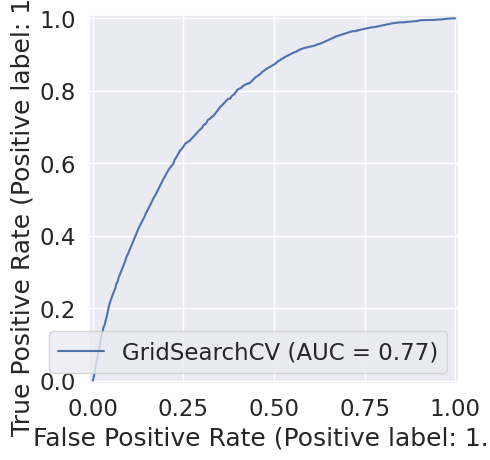

In [79]:
# Plot the ROC curve and calculate the AUC for the tuned HistGradientBoostingClassifier model
RocCurveDisplay.from_estimator(grid_search_hist, X_test, y_test);

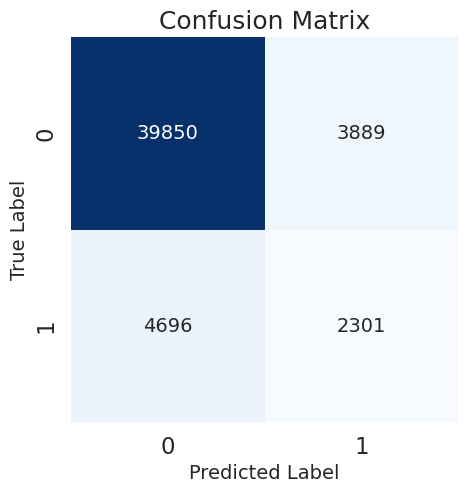

In [80]:
conf_matrix = confusion_matrix(y_test, y_preds)

# Plot the confusion matrix with improved readability
fig, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            annot_kws={"size": 14},
            ax=ax)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Confusion Matrix")
plt.show();

Now that we've got a ROC curve, an AUC metric and a confusion matrix, let's get a classification report as well as cross-validated precision, recall and f1-score

In [81]:
# Print classification report for model evaluation
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90     43739
         1.0       0.37      0.33      0.35      6997

    accuracy                           0.83     50736
   macro avg       0.63      0.62      0.63     50736
weighted avg       0.82      0.83      0.83     50736



### Calculate evaluation metrics using cross-validation

We're going to calculate accuracy, precision, recall and f1-score of our model using cross-validation and to do so, we'll be using'cross_val_score()'

In [82]:
# Output the best hyperparameters from GridSearchCV for HistGradientClassifier
grid_search_hist.best_params_

{'learning_rate': 0.05,
 'max_depth': 7,
 'max_iter': 250,
 'max_leaf_nodes': 30,
 'min_samples_leaf': 20}

In [83]:
# Initialize a new HistGradientBoostingClassifier with the best parameters
clf = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=7,
                                     max_iter=250, max_leaf_nodes=30,
                                     min_samples_leaf=20)

In [85]:
# Compute the cross-validated accuracy for the new HistGradientBoostingClassifier
cv_acc = np.mean(cross_val_score(clf, X, y, cv=5, scoring='accuracy'))
cv_acc

0.8667652160201829

In [86]:
# Compute the cross-validated precision for the new HistGradientBoostingClassifier
cv_precision = np.mean(cross_val_score(clf, X, y, cv=5, scoring="precision"))
cv_precision

0.5787729163949931

In [87]:
# Compute the cross-validated recall for the new HistGradientBoostingClassifier
cv_recall = np.mean(cross_val_score(clf, X, y, cv=5, scoring="recall"))
cv_recall

0.1568210824679663

In [88]:
# Compute the cross-validated f1-score for the new HistGradientBoostingClassifier
cv_f1 = np.mean(cross_val_score(clf, X, y, cv=5, scoring="f1"))
cv_f1

0.2479495170826072

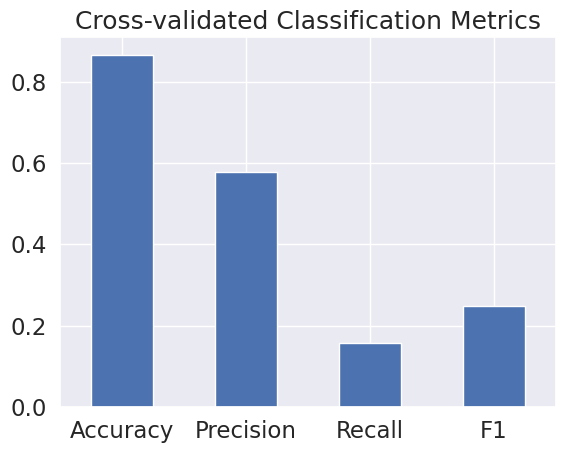

In [89]:
# Create a DataFrame for cross-validated metrics
cv_metrics = pd.DataFrame({
        "Accuracy": cv_acc,
        "Precision": cv_precision,
        "Recall": cv_recall,
        "F1": cv_f1
        }, index=[0])

# Plot the metrics
cv_metrics.T.plot.bar(title="Cross-validated Classification Metrics", legend=False)
plt.xticks(rotation=False);

### Feature Importance
Feature importance is another way of asking, "which features contributed most to the outcomes of the model and how did they contribute?"

Finding feature importance is different for each machine learning model. One way to find feature importance is to search for "(MODEL NAME) feature importance".

Let's find the feature importance for our HistGradientBoostingClassifier...

In [96]:
# Initialize and fit HistGradientBoostingClassifier with best parameters
clf = HistGradientBoostingClassifier(learning_rate=0.05, max_depth=7,
                                     max_iter=250, max_leaf_nodes=30,
                                     min_samples_leaf=20)

# Fit the model on the training data
clf.fit(X_train, y_train)

In [102]:
# Calculate permutation importance
result = permutation_importance(clf, X_test, y_test,
                                n_repeats=10, random_state=42)

In [104]:
importance_df = pd.DataFrame({
    "Feature": clf.feature_names_in_,
    "Importance": result.importances_mean
})

# Sort and display
importance_df = importance_df.sort_values(by="Importance", ascending=False)
importance_df

,Feature,Importance
3,BMI,0.007200
13,GenHlth,0.005138
0,HighBP,0.003516
1,HighChol,0.002899
18,Age,0.001717
6,HeartDiseaseorAttack,0.000816
10,HvyAlcoholConsump,0.000719
16,DiffWalk,0.000639
17,Sex,0.000560
15,PhysHlth,0.000339


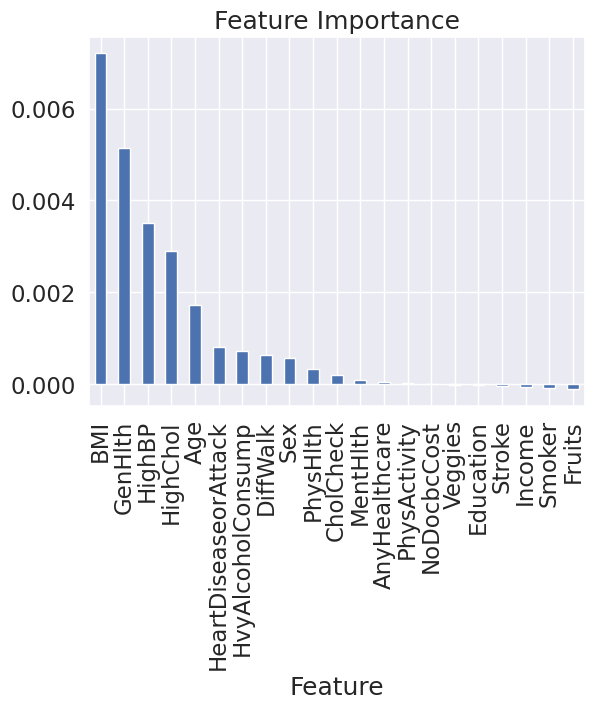

In [106]:
# Plot the feature importance
importance_df.plot.bar(x='Feature', y='Importance', title="Feature Importance", legend=False)
plt.xticks(rotation=90)  # Rotate feature names for better readability
plt.show()

In [111]:
!ls

catboost_info  drive  sample_data


In [112]:
!cp /content/drive/MyDrive/Diabetes/Predicting\ Diabetes.ipynb /content/drive/MyDrive/Diabetes/diabetes_binary_health_indicators_BRFSS2015.csv /content/Healthcare-Machine-Learning-Project/

cp: target '/content/Healthcare-Machine-Learning-Project/' is not a directory


In [113]:
!mkdir /content/Healthcare-Machine-Learning-Project